Please write your main code in this ipynb file. 

In [1]:
# import everything here
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.linalg import solve_banded

## Part 1: Construct the Yield Curve 

### 1. Import dicrete treasury data from the Federal Reserve Economic Data (FRED) database.

In [2]:
def get_treasury_yields_from_fred():
    # Define the duration (in years) and the corresponding FRED ID for each treasury yield
    yield_map = {
        1/12: "DGS1MO",
        3/12: "DGS3MO",
        6/12: "DGS6MO",
        1: "DGS1",
        2: "DGS2",
        3: "DGS3",
        5: "DGS5",
        7: "DGS7",
        10: "DGS10",
        20: "DGS20",
        30: "DGS30"
    }
    
    series_ids = list(yield_map.values())
    
    try:
        # Obtain the data for the last 5 days (make sure to get the latest and valid working day data)
        start = datetime(2026, 4, 1)
        df = web.DataReader(series_ids, 'fred', start)
        
        # Take the last non-empty row of data
        latest_data = df.dropna().iloc[-1]
        
        # Convert to DataFrame
        results = pd.DataFrame({
            'Maturity': yield_map.keys(),
            'Yield': latest_data.values
        }).sort_values('Maturity')
        
        return results
        
    except Exception as e:
        print(f"Failed to retrieve data: {e}")
        return None

# Execute retrieval
treasury_data = get_treasury_yields_from_fred()
print(treasury_data)

     Maturity  Yield
0    0.083333   3.66
1    0.250000   3.68
2    0.500000   3.71
3    1.000000   3.68
4    2.000000   3.78
5    3.000000   3.77
6    5.000000   3.91
7    7.000000   4.10
8   10.000000   4.29
9   20.000000   4.88
10  30.000000   4.90


### 2. Build the yield curve class with interpolation methods(piece wise and cubic spline), including the improved area-preserving quadratic spline (APQS) method.

In [4]:
class YieldCurve:
    def __init__(self, maturities, yields):
        idx = np.argsort(maturities)
        self.T = np.array(maturities)[idx]
        self.y = np.array(yields)[idx]
        self.m = len(self.T)
        
        # Step 1: yields -> discount factors
        self.df = np.exp(-self.y * self.T)
        
        # Step 2: discount factors -> piecewise constant forward rates
        # P(T_j) = exp(-integral_0^{T_j} f(t)dt)
        # For interval [T_{j-1}, T_j]: A[j] = -log(P(T_j)/P(T_{j-1})) / (T_j - T_{j-1})
        T_aug = np.insert(self.T, 0, 0.0)
        df_aug = np.insert(self.df, 0, 1.0)  # P(0) = 1
        delta = np.diff(T_aug)
        
        self.T_aug = T_aug
        self.delta = delta
        # A[j] = piecewise constant forward for interval j (0-indexed)
        self.A = -np.log(df_aug[1:] / df_aug[:-1]) / delta

    def get_interpolation(self, method='apqs'):
        if method == 'piecewise':
            # Return yield curve (convert forward back to yield for display)
            def pw_yield(t):
                t = np.atleast_1d(np.asarray(t, dtype=float))
                # Find which interval
                idx = np.searchsorted(self.T, t, side='left')
                idx = np.clip(idx, 0, self.m - 1)
                return self.y[idx]
            return pw_yield
        
        elif method == 'cubic':
            from scipy.interpolate import CubicSpline
            return CubicSpline(self.T, self.y, bc_type='natural')
        
        elif method == 'apqs':
            return self._build_apq_spline()

    def _build_apq_spline(self):
        T_aug = self.T_aug
        delta = self.delta
        A = self.A   # piecewise constant FORWARD rates, NOT yields
        n = self.m + 1

        ab = np.zeros((3, n))
        ab[1, :] = 1.0

        denom = delta[:-1] + delta[1:]
        w_lower = 0.5 * delta[1:] / denom
        w_upper = 0.5 * delta[:-1] / denom

        ab[2, 1:-1] = w_lower
        ab[0, 1:-1] = w_upper
        ab[0, 0] = 0.5
        ab[2, -1] = 0.5

        rhs = np.zeros(n)
        rhs[0] = 1.5 * A[0]
        rhs[-1] = 1.5 * A[-1]
        rhs[1:-1] = 1.5 * (delta[1:] * A[:-1] + delta[:-1] * A[1:]) / denom

        f_nodes = solve_banded((1, 1), ab, rhs)

        def forward_func(t):
            """Returns instantaneous forward rate f(t)"""
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)

            left_mask  = t <= T_aug[0]
            right_mask = t >= T_aug[-1]
            mid_mask   = ~(left_mask | right_mask)

            res[left_mask]  = f_nodes[0]
            res[right_mask] = f_nodes[-1]

            j = np.searchsorted(T_aug[1:], t[mid_mask], side='left')
            j = np.clip(j, 0, self.m - 1)
            t_mid = t[mid_mask]
            xi = (t_mid - T_aug[j]) / delta[j]

            f0 = f_nodes[j]
            f1 = f_nodes[j + 1]
            aj = A[j]
            res[mid_mask] = (f0*(1-xi) + f1*xi
                             - 3*(f0 + f1 - 2*aj)*xi*(1-xi))
            return res

        def yield_func(t):
            """
            Convert forward rate back to yield for display:
            y(T) = (1/T) * integral_0^T f(s) ds
            Computed numerically per query point.
            """
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)
            
            for i, ti in enumerate(t):
                if ti <= 0:
                    res[i] = f_nodes[0]
                else:
                    # Integrate f from 0 to ti using fine grid
                    s = np.linspace(0, ti, max(200, int(ti * 50)))
                    f_vals = forward_func(s)
                    res[i] = np.trapz(f_vals, s) / ti
            return res
        
        # Save the forward_func for use in get_forward_rate
        self._apqs_forward_func = forward_func
        return yield_func
    
    def get_forward_rate(self, t, method='apqs'):
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'apqs':
            if not hasattr(self, '_apqs_forward_func'):
                self._build_apq_spline()
            return self._apqs_forward_func(t)

        elif method == 'cubic':
            cs = CubicSpline(self.T, self.y, bc_type='natural')
            return np.where(t <= 0, cs(0), cs(t) + t * cs(t, 1))

        elif method == 'piecewise':
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            return self.A[j]

        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'apqs', 'cubic', 'piecewise'")


    def get_discount_factor(self, t, method='apqs'):
        """
        P(0,t) = exp(-∫_0^t f(s)ds)
        
        For piecewise, use the analytical formula (with no numerical errors and no need for loops)
        For apqs/cubic, use vectorized cumulative trapezoid
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'piecewise':
            # log P(0,t) = -sum_{j<j_end} A[j]*delta[j]  -  A[j_end]*(t - T_aug[j_end])
            #
            # First, calculate the cumulative log P value at each node for each interval.
            log_P_nodes = np.zeros(self.m + 1)
            log_P_nodes[1:] = -np.cumsum(self.A * self.delta)  # shape (m,)
            
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            
            # piecewise constant forward: log P(0,t) = log P at last node - A[j]*(t - T_aug[j])
            log_P = log_P_nodes[j] - self.A[j] * (t - self.T_aug[j])
            log_P[t <= 0] = 0.0
            return np.exp(log_P)

        else:
            # apqs / cubic: Calculate the integrals of all t values at once on the public fine grid.
            # Use cumulative trapezoid to avoid integrating each t separately
            t_max = np.max(t)
            n_grid = max(2000, int(t_max * 100))
            s = np.linspace(0, t_max, n_grid)          # public fine grid
            f_vals = self.get_forward_rate(s, method=method)
            
            # cumulative integral F(s) = ∫_0^s f(u)du
            from scipy.integrate import cumulative_trapezoid
            F = np.zeros(n_grid)
            F[1:] = cumulative_trapezoid(f_vals, s)    # shape (n_grid,)
            
            # For each query point t, interpolate F(t)
            F_interp = np.interp(t, s, F)
            result = np.exp(-F_interp)
            result[t <= 0] = 1.0
            return result


    def get_zero_rate(self, t, method='apqs'):
        """
        y(t) = -log(P(0,t)) / t
        use get_discount_factor
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        P = self.get_discount_factor(t, method=method)
        
        result = np.empty_like(t, dtype=float)
        nonzero = t > 0
        result[nonzero] = -np.log(P[nonzero]) / t[nonzero]
        result[~nonzero] = self.get_forward_rate(np.array([1e-8]), method=method)[0]
        return result

### 3. Visualization of the curves with different interpolation methods(piece wise and cubic spline, area-preserving quadratic spline (APQS) method).

/var/folders/0y/6xh69jq14ds_k68d46wzj7n00000gn/T/ipykernel_22091/349340581.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res[i] = np.trapz(f_vals, s) / ti


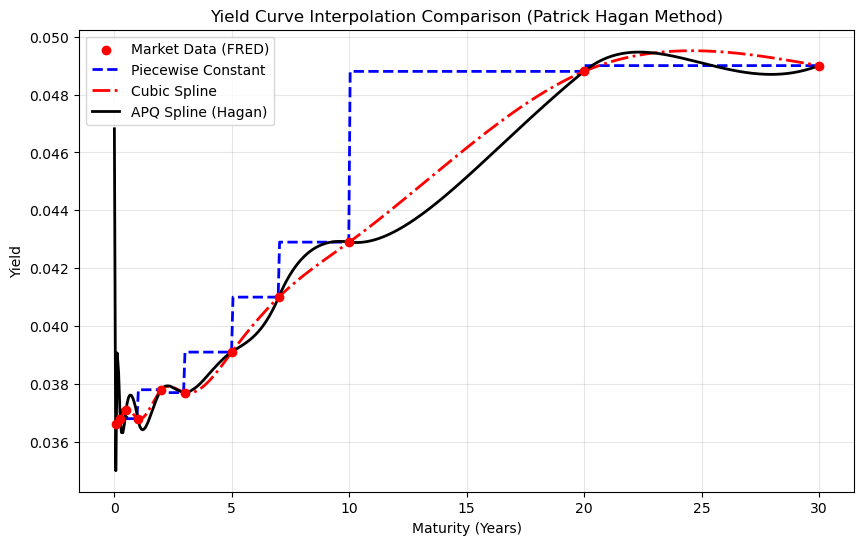

In [5]:
# Prepare Data (Assumes treasury_data from previous step)
# Convert yield to decimal for calculation (e.g., 4.5% -> 0.045)
maturities = treasury_data['Maturity'].values
yields = treasury_data['Yield'].values / 100.0

# Instantiate and Generate Curves
curve_builder = YieldCurve(maturities, yields)
t_range = np.linspace(0, 30, 500)

methods = {
    'Piecewise Constant': ('piecewise', 'blue', '--'),
    'Cubic Spline': ('cubic', 'red', '-.'),
    'APQ Spline (Hagan)': ('apqs', 'black', '-')
}

plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color='red', label='Market Data (FRED)', zorder=5)

for label, (m, color, style) in methods.items():
    f_interp = curve_builder.get_interpolation(method=m)
    plt.plot(t_range, f_interp(t_range), label=label, color=color, linestyle=style, lw=2)

plt.title("Yield Curve Interpolation Comparison (Patrick Hagan Method)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 2 Calibrate and Simulate Interest Rate Paths

### Interface Documentation: Part 1 to Part 2

### 1. Initialize YieldCurve
curve = YieldCurve(maturities, yields)
#### method options: 'apqs' (recommended), 'cubic', 'piecewise'

### 2. Available interfaces from Part 2

#### Instantaneous forward rate f(0,t) — used to compute θ(t)
f = curve.get_forward_rate(t, method='apqs')

### Initial short rate r(0) — starting point for simulation
r0 = curve.get_forward_rate(np.array([1e-6]), method='apqs')[0]

### Discount factor P(0,T) — only needed if you are calibrating a and sigma from market data
P = curve.get_discount_factor(t, method='apqs')

### 3. Pass into your HullWhiteModel
hw = HullWhiteModel(curve, a=..., sigma=..., method='apqs')

### 1. Interface from Part 1

In [ ]:
maturities = treasury_data["Maturity"].values
yields = treasury_data["Yield"].values / 100

curve = YieldCurve(maturities, yields)
method = "apqs"  #alternatives: 'cubic', 'piecewise'

t_curve = np.linspace(0.001, 30, 500)
f0t = curve.get_forward_rate(t_curve, method=method)
P0T = curve.get_discount_factor(t_curve, method=method)
r0 = curve.get_forward_rate(np.array([1e-6]), method=method)[0]

print("Initial short rate r(0):", r0)
print("Example forward rate f(0,5):", curve.get_forward_rate(np.array([5]), method=method)[0])
print("Example discount factor P(0,10):", curve.get_discount_factor(np.array([10]), method=method)[0])


Initial short rate r(0): 0.046815715284842435
Example forward rate f(0,5): 0.04181695137915986
Example discount factor P(0,10): 0.6511593837053569


### 2. 2-Factor Hull-White Model

In [ ]:
#Model specification:
# r(t) = x(t) + y(t) + phi(t)
# dx(t) = -a x(t) dt + sigma dW1(t)
# dy(t) = -b y(t) dt + eta dw2(t)
# corr(dW1, dW2) = rho

class HullWhiteModel:
    def __init__(self, yield_curve, a: float, b: float, sigma: float, eta: float, rho: float, method: str = 'apqs'):
        """
        yield_curve: YieldCurve object from Part 1
        Initialize the 2-factor Hull-White model with the given yield curve,
        mean reversion speeds a and b, volatilities sigma and eta,
        correlation rho, and interpolation method.
        """
        self.curve = yield_curve
        self.a = a
        self.b = b
        self.sigma = sigma
        self.eta = eta
        self.rho = rho
        self.method = method


    def f0(self, t):
        """
        Initial instantaneous forward rate f(0,t) from yield curve
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        return self.curve.get_forward_rate(t, method=self.method)

    def phi(self, t):
        """
        Deterministic shift phi(t)

        phi(t) = f(0,t)
                 + (sigma^2 / (2a^2)) * (1 - e^{-at})^2
                 + (eta^2   / (2b^2)) * (1 - e^{-bt})^2
                 + (rho*sigma*eta/(ab)) * (1 - e^{-at})(1 - e^{-bt})
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        
        term1 = (self.sigma ** 2 / (2 * self.a ** 2)) * (1 - np.exp(-self.a * t)) ** 2
        term2 = (self.eta ** 2   / (2 * self.b ** 2)) * (1 - np.exp(-self.b * t)) ** 2
        term3 = (self.rho * self.sigma * self.eta / (self.a * self.b)) \
                * (1 - np.exp(-self.a * t)) * (1 - np.exp(-self.b * t))

        return self.f0(t) + term1 + term2 + term3


    def simulate(self, T: float, n_steps: int, n_paths: int, seed: int = None):
        """
        Simulate the two latent factors x(t), y(t), then construct
            r(t) = x(t) + y(t) +phi(t) 
        using Euler.
        """
        if seed is not None:
            np.random.seed(seed)
        
        dt = T / n_steps
        sqrt_dt = np.sqrt(dt)
        t_grid = np.linspace(0, T, n_steps + 1)

        x_paths = np.zeros((n_paths, n_steps + 1))
        y_paths = np.zeros((n_paths, n_steps + 1))
        rates = np.zeros((n_paths, n_steps + 1))

        #Correlated Brownian shocks
        z1 = np.random.normal(size=(n_paths, n_steps))
        z2_indep = np.random.normal(size=(n_paths, n_steps))
        z2 = self.rho * z1 + np.sqrt(1 - self.rho ** 2) * z2_indep

        phi_grid = self.phi(t_grid)

        #Initial short rate from the initial forward curve
        r0 = curve.get_forward_rate(np.array([1e-6]), method=method)[0]

        #Initial conditions
        x_paths[:, 0] = 0
        y_paths[:, 0] = 0
        rates[:, 0] = r0 


        for i in range(n_steps):
            x_paths[:, i + 1] = (x_paths[:, i] + (-self.a * x_paths[:, i]) * dt 
                                 + self.sigma * sqrt_dt * z1[:, i])

            y_paths[:, i + 1] = (y_paths[:, i] + (-self.b * y_paths[:, i]) * dt 
                                 + self.eta * sqrt_dt * z2[:, i])
            
            rates[:, i + 1] = x_paths[:, i + 1] + y_paths[:, i + 1] + phi_grid[i + 1]
         
        
        return rates, x_paths, y_paths, t_grid

In [33]:
# Example parameters

a = 0.5        # faster mean reversion factor
b = 0.08       # slower mean reversion factor
sigma = 0.015  # volatility
eta = 0.008    # volatility
rho = -0.7     #correlation between factor shocks

hw = HullWhiteModel(curve, a=a, b=b, sigma=sigma, eta=eta, rho=rho, method=method)

### 3. Simulate Short-Rate Paths

In [34]:
T_sim = 10
n_steps = 500
n_paths = 1000

rates, x_paths, y_paths, t_grid = hw.simulate(T=T_sim, n_steps=n_steps, n_paths=n_paths, seed=42)

print("rates shape:", rates.shape)
print("x_paths shape:", x_paths.shape)
print("y_paths shape:", y_paths.shape)
print("t_grid shape:", t_grid.shape)

rates shape: (1000, 501)
x_paths shape: (1000, 501)
y_paths shape: (1000, 501)
t_grid shape: (501,)


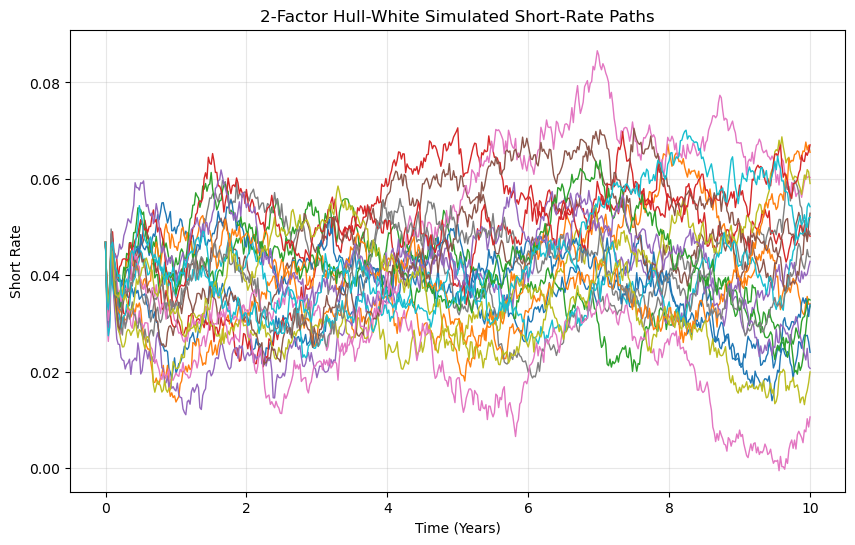

In [35]:
# Plot simulated short-rate paths

plt.figure(figsize=(10, 6))
for i in range(20):
    plt.plot(t_grid, rates[i], lw=1)

plt.title("2-Factor Hull-White Simulated Short-Rate Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.grid(True, alpha=0.3)
plt.show()

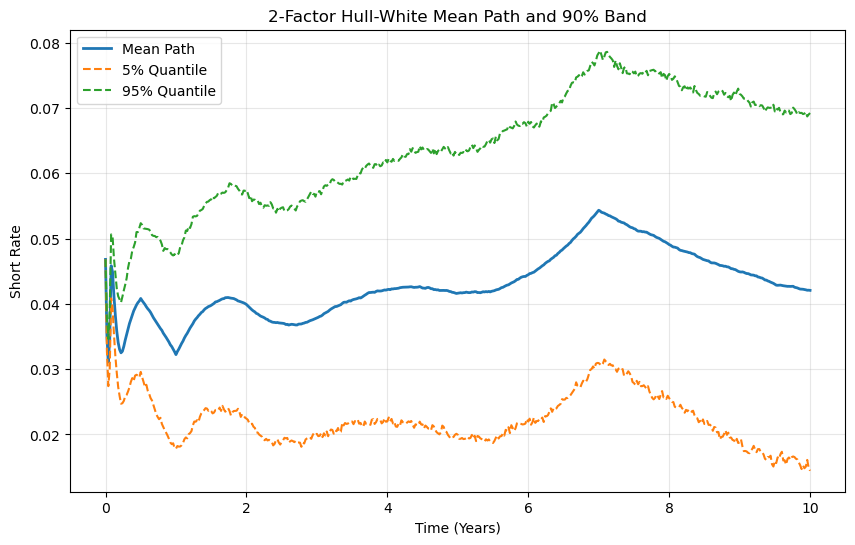

In [36]:
mean_path = rates.mean(axis=0)
q05 = np.quantile(rates, 0.05, axis=0)
q95 = np.quantile(rates, 0.95, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, mean_path, label="Mean Path", lw=2)
plt.plot(t_grid, q05, linestyle="--", label="5% Quantile")
plt.plot(t_grid, q95, linestyle="--", label="95% Quantile")
plt.title("2-Factor Hull-White Mean Path and 90% Band")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
n_paths, n_times = rates.shape

short_rate_df = pd.DataFrame({"path_id": np.repeat(np.arange(n_paths), n_times),
                              "time_years": np.tile(t_grid, n_paths),
                              "month": np.tile(np.round(t_grid * 12).astype(int), n_paths),
                              "short_rate": rates.reshape(-1)})

short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.046816
1,0,0.02,0,0.034920
2,0,0.04,0,0.030010
3,0,0.06,1,0.035008
4,0,0.08,1,0.048585
...,...,...,...,...
500995,999,9.92,119,0.031417
500996,999,9.94,119,0.031550
500997,999,9.96,120,0.031332
500998,999,9.98,120,0.031658


### Part 3 Model Nonlinear Prepayment Behavior under changing interest rate conditions

In [ ]:
# Replace 'path_to_file.xlsx' with your actual file path
df = pd.read_excel('FRE_DPR_Cumulative.xlsx')
df['CPR']

In [ ]:
#Converting SMM into CPR.
df['SMM_calc'] = (df['Unscheduled Principal Reduction Amount'] / df['Cohort Current UPB'])
df['CPR_calc'] = (1-(1-(df['SMM_calc']))**12)
df['CPR_calc'] *=100 #empircal cpr

#Converting SMM into CPR.
df['SMM_calc'] = (df['Unscheduled Principal Reduction Amount'] / df['Cohort Current UPB'])
df['CPR_calc'] = (1-(1-(df['SMM_calc']))**12)
df['CPR_calc'] *=100 #empircal cpr

#data testing
(df['CPR_calc'] == 0).sum()
(df['CPR_calc'] == 0).mean()
df[df['CPR_calc'] == 0].iloc[0]
df[df['CPR_calc'] == 0].head() #boolean mask and filter rows.


In [ ]:
#data testing: 
df[df['CPR']==0].iloc[0]
#CPR is 0, since no prepayment was made at this factor date. however, we see CPR cumulative as 30 percent meaning prepayment made 30 percent so far of original balance.

#refinance incentive:
df['refinancing incentive_calc'] = (df['Cohort WA Current Interest Rate']/100) - 0.06

In [ ]:
#data checking.
df['refinancing incentive_calc'].mean()
df['Cohort WA Current Loan Age'].mean()
scohort_view = df[[
    'Cohort WA Current Loan Age',
    'Cohort WA Current Interest Rate',
    'Cohort Current UPB'
]].drop_duplicates().reset_index(drop=True)
(df['CPR_calc'] == 0).sum()

In [ ]:
df['age_bucket'] = pd.cut(
    df['Cohort WA Current Loan Age'],
    bins=[0, 60, 120, 180, 240, 360],
    labels=['0-5y','5-10y','10-15y','15-20y','20y+']
)
grouped = df.groupby('age_bucket')
CPR_min_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] < -0.005]['CPR_calc']
)
CPR_max_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] > 0.01]['CPR_calc'].mean()
)

In [ ]:
CPR_min_age.value_counts()
df.dtypes

In [ ]:
monthly = df.groupby([
    'Cohort WA Current Remaining Months to Maturity',
    'Factor Date'
]).agg({
    'CPR_calc': 'mean',
    'SMM_calc': 'mean',
    'Cohort WA Current Interest Rate': 'first',
    'Cohort Current UPB': 'first'
}).reset_index()


In [ ]:
low = df[df['refinancing incentive_calc'] < -0.005]['CPR_calc']
high = df[df['refinancing incentive_calc'] > 0.01]['CPR_calc']
CPR_min = low.mean()
CPR_max = high.mean()
print(CPR_min, CPR_max)

In [ ]:
#there are two strategies to design min CPR and max CPR. from incentives to quantile range. for now we do quantile range.
q20 = df['refinancing incentive_calc'].quantile(0.2) #isit right to have / use 20 quantile and 80 quantile?
q80 = df['refinancing incentive_calc'].quantile(0.8)

df['CPR_min'] = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].mean()
df['CPR_max'] = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].mean()

print(CPR_min, CPR_max)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
k = 150      # steepness (tune later)
theta = 0   # midpoint

df['CPR_model'] = df['CPR_min'] + (
    (df['CPR_max'] - df['CPR_min']) *
    (1 / (1 + np.exp(-k * (df['refinancing incentive_calc'] - theta))))
)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)
df[['CPR_min', 'CPR_model', 'CPR_max']].head()

import seaborn as sns

sns.scatterplot(
    x='refinancing incentive_calc',
    y='CPR_model',
    data=df,
    alpha=0.1
)
plt.xlabel('Refinancing Incentive (I_t)')
plt.ylabel('CPR')
plt.title('CPR vs Incentive (Logistic Model)')
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
#might have to use logistic curve for instead of truncating the data.

In [ ]:
fit_df = df[['refinancing incentive_calc', 'CPR_calc']].dropna().copy()
x = fit_df['refinancing incentive_calc'].values
y = fit_df['CPR_calc'].values

k_fixed = 30
theta_fixed = 0.0

def logistic_cpr_fixed(I, cpr_min, cpr_max):
    return cpr_min + (cpr_max - cpr_min) / (1 + np.exp(-k_fixed * (I - theta_fixed)))

params, cov = curve_fit(
    logistic_cpr_fixed,
    x,
    y,
    p0=[y.min(), y.max()],
    bounds=([0.0, 0.0], [1.0, 1.0]),
    maxfev=20000
)
cpr_min_hat, cpr_max_hat = params
print("CPR_min =", cpr_min_hat)
print("CPR_max =", cpr_max_hat)

df['CPR_model'] = logistic_cpr_fixed(df['refinancing incentive_calc'], cpr_min_hat, cpr_max_hat)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)

In [ ]:
#make min and max as distribution, not deterministic.
def draw_cpr_bounds(df, q20, q80):
    low = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].dropna().values
    high = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].dropna().values
    cpr_min_s = np.mean(np.random.choice(low, size=len(low), replace=True))
    cpr_max_s = np.mean(np.random.choice(high, size=len(high), replace=True))

    # enforce ordering
    cpr_min_s, cpr_max_s = min(cpr_min_s, cpr_max_s), max(cpr_min_s, cpr_max_s)
    return cpr_min_s, cpr_max_s

def simulate_cpr_path_full(I_path, df, q20, q80):
    # draw random bounds
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)

    # logistic mean with random bounds
    cpr_mean = cpr_min_s + (cpr_max_s - cpr_min_s) / (
        1 + np.exp(-k_hat * (I_path - theta_hat))
    )

    # residual noise
    residuals = df['residual'].dropna().values
    eps = np.random.choice(residuals, size=len(I_path), replace=True)

    cpr_sim = cpr_mean + eps
    cpr_sim = np.clip(cpr_sim, 0, 1)

    return cpr_sim
#testing to simulate the path.
for i in range(5):
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)
    print(i, cpr_min_s, cpr_max_s)
mins = []
maxs = []
for _ in range(1000):
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)
    mins.append(cpr_min_s)
    maxs.append(cpr_max_s)
mins = np.array(mins)
maxs = np.array(maxs)
print("CPR_min mean:", mins.mean())
print("CPR_min std :", mins.std())
print("CPR_min 5/95:", np.percentile(mins, [5, 95]))
print("CPR_max mean:", maxs.mean())
print("CPR_max std :", maxs.std())
print("CPR_max 5/95:", np.percentile(maxs, [5, 95]))
df['CPR_calc'].nlargest(30)
df['CPR_calc'].nsmallest(30)

In [ ]:
def draw_cpr_bounds_from_cpr(df, lower_q=0.2, upper_q=0.8):
    # define tails directly from CPR distribution

    cpr = df['CPR_calc'].dropna().values 
    #assign the threshold first.
    low = cpr[cpr <= np.quantile(cpr, lower_q)]  #converts pandas object into numpy arrays.
    high = cpr[cpr >= np.quantile(cpr, upper_q)]
    # enforce ordering
    # define tails directly from CPR distribution

    # bootstrap means / bootstrap resampling method. creates code to select list of simulations
    # as low to max through randomized selections from the list of integers/ decimals from the list.
    cpr_min_s = np.mean(np.random.choice(low, size=len(low), replace=True))
    cpr_max_s = np.mean(np.random.choice(high, size=len(high), replace=True))
    # runs through error testing.

    cpr_min_s, cpr_max_s = min(cpr_min_s, cpr_max_s), max(cpr_min_s, cpr_max_s)

    return cpr_min_s, cpr_max_s


In [ ]:
def simulate_cpr_path_full(I_path, df):
    # draw bounds from CPR distribution (not incentive)
    cpr_min_s, cpr_max_s = draw_cpr_bounds_from_cpr(df)

    # logistic CPR path
    cpr_mean = cpr_min_s + (cpr_max_s - cpr_min_s) / (
        1 + np.exp(-k_hat * (I_path - theta_hat))
    )

    # residual noise
    residuals = df['residual'].dropna().values
    eps = np.random.choice(residuals, size=len(I_path), replace=True)

    cpr_sim = cpr_mean + eps
    cpr_sim = np.clip(cpr_sim, 0, 1)

    return cpr_sim

In [ ]:
mins, maxs = [], []

for _ in range(1000):
    cpr_min_s, cpr_max_s = draw_cpr_bounds_from_cpr(df)
    mins.append(cpr_min_s)
    maxs.append(cpr_max_s)

mins = np.array(mins)
maxs = np.array(maxs)

print("CPR_min mean:", mins.mean())
print("CPR_min std :", mins.std())
print("CPR_min 5/95:", np.percentile(mins, [5, 95]))

print("CPR_max mean:", maxs.mean())
print("CPR_max std :", maxs.std())
print("CPR_max 5/95:", np.percentile(maxs, [5, 95]))